### Step 5: System Vulnerabilities (Breaking the Model)
**Objective:** Prove that outliers strongly affect squared-error objectives, and that multicollinearity makes coefficients unstable[cite: 2].

#### Experiment A: The Massive Outlier
Because OLS (Ordinary Least Squares) minimizes *squared* residuals, a single massive error will force the optimization engine to drastically tilt the mathematical line to compensate. We will inject one corrupted data point and watch the metrics explode.

--- OUTLIER EXPERIMENT RESULTS ---
Clean Model MSE: 54.60
Clean Model R^2: 0.9968
Corrupted Model MSE: 792,048.59
Corrupted Model R^2: 0.2359


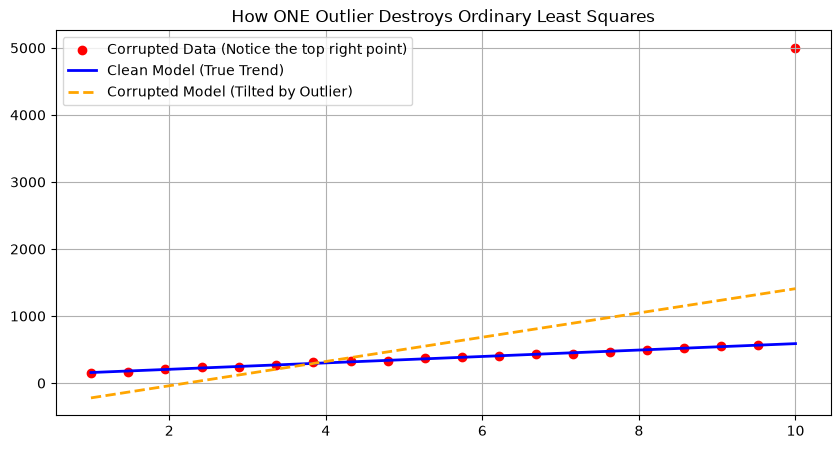

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Create a clean, perfect linear dataset
np.random.seed(42)
X_clean = np.linspace(1, 10, 20).reshape(-1, 1)
y_clean = (50 * X_clean.flatten()) + 100 + np.random.normal(0, 10, 20)

# 2. Train a model on the clean data
model_clean = LinearRegression()
model_clean.fit(X_clean, y_clean)
y_pred_clean = model_clean.predict(X_clean)
mse_clean = mean_squared_error(y_clean, y_pred_clean)

# 3. Inject ONE massive outlier (e.g., a data entry glitch)
y_corrupted = y_clean.copy()
y_corrupted[19] = 5000 # The last data point is artificially inflated to 5000

# 4. Train a model on the corrupted data
model_corrupted = LinearRegression()
model_corrupted.fit(X_clean, y_corrupted)
y_pred_corrupted = model_corrupted.predict(X_clean)
mse_corrupted = mean_squared_error(y_corrupted, y_pred_corrupted)

# 5. Print the damage
print("--- OUTLIER EXPERIMENT RESULTS ---")
print(f"Clean Model MSE: {mse_clean:,.2f}")
print(f"Clean Model R^2: {r2_score(y_clean, y_pred_clean):.4f}")
print(f"Corrupted Model MSE: {mse_corrupted:,.2f}")
print(f"Corrupted Model R^2: {r2_score(y_corrupted, y_pred_corrupted):.4f}")

# 6. Visualize the structural collapse
plt.figure(figsize=(10, 5))
plt.scatter(X_clean, y_corrupted, color='red', label='Corrupted Data (Notice the top right point)')
plt.plot(X_clean, y_pred_clean, color='blue', label='Clean Model (True Trend)', linewidth=2)
plt.plot(X_clean, y_pred_corrupted, color='orange', linestyle='--', label='Corrupted Model (Tilted by Outlier)', linewidth=2)
plt.title("How ONE Outlier Destroys Ordinary Least Squares")
plt.legend()
plt.grid(True)
plt.show()

#### Experiment B: Multicollinearity (Redundant Data)
Multicollinearity occurs when two features are highly correlated (e.g., tracking "Salary in USD" and "Salary in EUR" as separate features). This confuses the mathematical engine because it cannot figure out which feature is actually driving the target, making the coefficients wildly unstable[cite: 2].

In [2]:
# 1. Create a dataset with perfectly redundant features
# Feature 1: Experience in Years
X_years = np.random.uniform(1, 10, 100).reshape(-1, 1)

# Feature 2: Experience in Months (Exactly X_years * 12 + a tiny bit of noise)
# This is mathematically redundant. It is the exact same signal.
X_months = (X_years * 12) + np.random.normal(0, 0.1, (100, 1))

# Target: Salary
y_salary = (5000 * X_years.flatten()) + 30000 + np.random.normal(0, 2000, 100)

# 2. Combine the features
X_redundant = np.hstack((X_years, X_months))

# 3. Train the model
model_multi = LinearRegression()
model_multi.fit(X_redundant, y_salary)

# 4. Observe the unstable coefficients
print("\n--- MULTICOLLINEARITY EXPERIMENT RESULTS ---")
print(f"Weight for Years (w1): {model_multi.coef_[0]:,.2f}")
print(f"Weight for Months (w2): {model_multi.coef_[1]:,.2f}")
print("Notice how the weights are arbitrary, massive, or negative! ")
print("The math engine is collapsing because it cannot distribute the weight between two identical signals.")


--- MULTICOLLINEARITY EXPERIMENT RESULTS ---
Weight for Years (w1): 8,943.09
Weight for Months (w2): -333.62
Notice how the weights are arbitrary, massive, or negative! 
The math engine is collapsing because it cannot distribute the weight between two identical signals.
